In [122]:
import Pkg
Pkg.add([
        "CSV",
        "DataFrames",
        "Glob",
        "Makie",
        "CairoMakie"
        ])

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [325]:
import CSV
using DataFrames
using Glob
using Makie, CairoMakie
using Statistics

In [211]:
colset = [
    "match_id",
    "ElapsedTime",
    "SetNo",
    "P1GamesWon",
    "P2GamesWon",
    "SetWinner",
    "GameNo",
    "GameWinner",
    "PointNumber",
    "PointWinner",
    "PointServer",
    "Speed_KMH",
    "P1Score",
    "P2Score",
    "P1PointsWon",
    "P2PointsWon",
    "P1Ace",
    "P2Ace",
    "P1Winner",
    "P2Winner",
    "P1DoubleFault",
    "P2DoubleFault",
    "P1UnfErr",
    "P2UnfErr",
    "P1BreakPoint",
    "P2BreakPoint",
    "P1BreakPointWon",
    "P2BreakPointWon",
    "P1SecondSrvIn",
    "P2SecondSrvIn",
    "P1SecondSrvWon",
    "P2SecondSrvWon",
    "P1ForcedError",
    "P2ForcedError"
]

34-element Vector{String}:
 "match_id"
 "ElapsedTime"
 "SetNo"
 "P1GamesWon"
 "P2GamesWon"
 "SetWinner"
 "GameNo"
 "GameWinner"
 "PointNumber"
 "PointWinner"
 "PointServer"
 "Speed_KMH"
 "P1Score"
 ⋮
 "P1UnfErr"
 "P2UnfErr"
 "P1BreakPoint"
 "P2BreakPoint"
 "P1BreakPointWon"
 "P2BreakPointWon"
 "P1SecondSrvIn"
 "P2SecondSrvIn"
 "P1SecondSrvWon"
 "P2SecondSrvWon"
 "P1ForcedError"
 "P2ForcedError"

In [212]:
dfs = Dict(basename(f) => CSV.read(f, DataFrame) for f in glob("*points.csv", "tennis-data"))
tournaments = keys(dfs) |> collect |> sort
sorted_dfs = [dfs[t] for t in tournaments]
common_cols = intersect([names(df) for df in sorted_dfs]...);

In [213]:
all_matches = vcat([select!(df, colset) for df in sorted_dfs]...)

Row,match_id,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,PointServer,Speed_KMH,P1Score,P2Score,P1PointsWon,P2PointsWon,P1Ace,P2Ace,P1Winner,P2Winner,P1DoubleFault,P2DoubleFault,P1UnfErr,P2UnfErr,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,P1SecondSrvIn,P2SecondSrvIn,P1SecondSrvWon,P2SecondSrvWon,P1ForcedError,P2ForcedError
,String31,Any,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Any,Int64?,Int64?,Int64?,String7?,String7?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?
1,2011-ausopen-1101,00:00:00,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2011-ausopen-1101,00:00:00,1,0,0,0,1,0,1,1,2,166,15,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,2011-ausopen-1101,00:00:23,1,0,0,0,1,0,2,1,2,132,30,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,2011-ausopen-1101,00:00:59,1,0,0,0,1,0,3,1,2,144,40,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
5,2011-ausopen-1101,00:01:57,1,1,0,0,1,1,4,1,2,137,0,0,4,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0
6,2011-ausopen-1101,00:03:23,1,1,0,0,2,0,5,1,1,149,15,0,5,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
7,2011-ausopen-1101,00:04:04,1,1,0,0,2,0,6,1,1,201,30,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
8,2011-ausopen-1101,00:04:27,1,1,0,0,2,0,7,2,1,0,30,15,6,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
9,2011-ausopen-1101,00:05:01,1,1,0,0,2,0,8,1,1,171,40,15,7,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [314]:
df = all_matches
missing_bps = df[ismissing.(df.P1BreakPoint) .|| ismissing.(df.P2BreakPoint), :match_id] |> unique
df = df[df.match_id .∉ Ref(missing_bps),:];
missing_points = df[ismissing.(df.PointWinner) .|| ismissing.(df.PointNumber), :match_id] |> unique
df = df[df.match_id .∉ Ref(missing_points),:];

println("Removed missing: $(length(union(Set(missing_bps), Set(missing_points))))")

In [315]:
# add match tournament and year columns
function from_matchid(mid)
    (year, tmnt) = match(r"(\d{4})-([a-z]+)", mid)
    year = parse(Int, year)
    permutedims([year, tmnt])
end

yr_tmnt = vcat(from_matchid.(df.match_id)...)
insertcols!(df, 2, :Year => yr_tmnt[:,1], :Tmnt => yr_tmnt[:,2])

Row,match_id,Year,Tmnt,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,PointServer,Speed_KMH,P1Score,P2Score,P1PointsWon,P2PointsWon,P1Ace,P2Ace,P1Winner,P2Winner,P1DoubleFault,P2DoubleFault,P1UnfErr,P2UnfErr,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,P1SecondSrvIn,P2SecondSrvIn,P1SecondSrvWon,P2SecondSrvWon,P1ForcedError,P2ForcedError
,String31,Any,Any,Any,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Any,Int64?,Int64?,Int64?,String7?,String7?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?
1,2011-ausopen-1101,2011,ausopen,00:00:00,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2011-ausopen-1101,2011,ausopen,00:00:00,1,0,0,0,1,0,1,1,2,166,15,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,2011-ausopen-1101,2011,ausopen,00:00:23,1,0,0,0,1,0,2,1,2,132,30,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,2011-ausopen-1101,2011,ausopen,00:00:59,1,0,0,0,1,0,3,1,2,144,40,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
5,2011-ausopen-1101,2011,ausopen,00:01:57,1,1,0,0,1,1,4,1,2,137,0,0,4,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0
6,2011-ausopen-1101,2011,ausopen,00:03:23,1,1,0,0,2,0,5,1,1,149,15,0,5,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
7,2011-ausopen-1101,2011,ausopen,00:04:04,1,1,0,0,2,0,6,1,1,201,30,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
8,2011-ausopen-1101,2011,ausopen,00:04:27,1,1,0,0,2,0,7,2,1,0,30,15,6,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
9,2011-ausopen-1101,2011,ausopen,00:05:01,1,1,0,0,2,0,8,1,1,171,40,15,7,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [316]:
insertcols!(df, 4, :MatchNum => missing)
for gdf in groupby(df, :Year)
    gdf[!,:MatchNum] = groupindices(groupby(gdf, :match_id))
end

In [317]:
gdf = groupby(df, :match_id)

Row,match_id,Year,Tmnt,MatchNum,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,PointServer,Speed_KMH,P1Score,P2Score,P1PointsWon,P2PointsWon,P1Ace,P2Ace,P1Winner,P2Winner,P1DoubleFault,P2DoubleFault,P1UnfErr,P2UnfErr,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,P1SecondSrvIn,P2SecondSrvIn,P1SecondSrvWon,P2SecondSrvWon,P1ForcedError,P2ForcedError
,String31,Any,Any,Int64?,Any,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Any,Int64?,Int64?,Int64?,String7?,String7?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?
1,2011-ausopen-1101,2011,ausopen,1,00:00:00,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2011-ausopen-1101,2011,ausopen,1,00:00:00,1,0,0,0,1,0,1,1,2,166,15,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,2011-ausopen-1101,2011,ausopen,1,00:00:23,1,0,0,0,1,0,2,1,2,132,30,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,2011-ausopen-1101,2011,ausopen,1,00:00:59,1,0,0,0,1,0,3,1,2,144,40,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
5,2011-ausopen-1101,2011,ausopen,1,00:01:57,1,1,0,0,1,1,4,1,2,137,0,0,4,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0
6,2011-ausopen-1101,2011,ausopen,1,00:03:23,1,1,0,0,2,0,5,1,1,149,15,0,5,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
7,2011-ausopen-1101,2011,ausopen,1,00:04:04,1,1,0,0,2,0,6,1,1,201,30,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
8,2011-ausopen-1101,2011,ausopen,1,00:04:27,1,1,0,0,2,0,7,2,1,0,30,15,6,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
9,2011-ausopen-1101,2011,ausopen,1,00:05:01,1,1,0,0,2,0,8,1,1,171,40,15,7,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [394]:
pws = zeros(length(gdf))
bpws = zeros(Union{Float64, Missing}, length(gdf))
for (i,g) in enumerate(gdf)
    nbp = sum(g.P1BreakPoint)
    bpw = nbp > 0 ? 
        sum(g.P1BreakPointWon) / nbp :
        -1
    npoints = sum(g.PointWinner .!= 0)
    pw = sum(g.PointWinner .== 1) / npoints
    pws[i] = pw
    bpws[i] = bpw
end
# filter!((!) ∘ iszero, bps);

In [376]:
p1ws = [(df.match_id[1], sum(df.PointWinner .== 1)) for df in gdf];

In [380]:
filter(x -> x[2] == 0, p1ws)

1-element Vector{Tuple{InlineStrings.String31, Int64}}:
 ("2022-usopen-2160", 0)

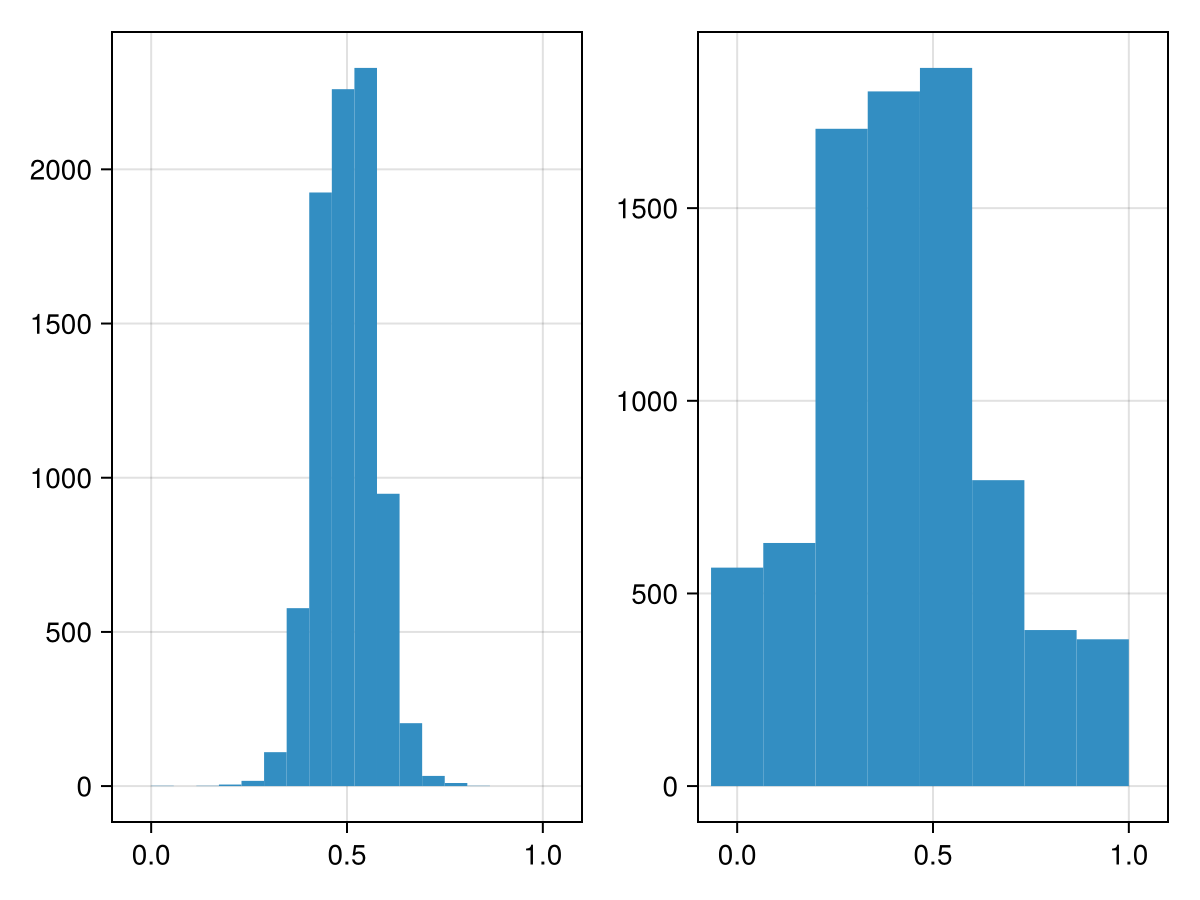

In [406]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    kwargs...
)
f = Figure()
mkax(f[1,1])
hist!(pws)
mkax(f[1,2])
hist!(bpws)
f

In [345]:
bps

16842-element Vector{Union{Missing, Float64}}:
 0.0
 1.2448979591836735
 0.0
 0.8932038834951456
 0.55
 1.1
 0.9006342494714588
 0.0
 0.996243425995492
 0.6629999999999999
 0.4666666666666667
 1.0
 1.6968750000000001
 ⋮
 1.2249999999999999
 1.1264367816091954
 0.8872549019607843
 0.7637130801687764
 0.685483870967742
 1.3117283950617284
 0.6775362318840579
 1.3122807017543858
 0.8841698841698841
 0.5544794188861986
 0.706140350877193
 0.8117647058823529